In [7]:
# Install system dependencies for PDF processing (Required for Kaggle/Colab)
!apt-get update && apt-get install -y poppler-utils

# Install Python libraries
!pip install scenedetect pdf2image transformers torch torchvision opencv-python scikit-image tqdm matplotlib seaborn pandas

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease                     
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,632 B in 1s (2,731 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as re

Directories & Configuration

In [8]:
import os
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

# --- YOUR DATASET PLACEHOLDERS ---
# Fill these in with your exact file paths
VIDEOS = {
    "Video_1": "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 04. Architectures Grids.mp4",
    "Video_2": "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 11. Representation Learning Reconstruction-Based.mp4",
    "Video_3": "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 18. Transfer Learning Models.mp4"
}

PDF_NOTES = {
    "Video_1": "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec04.pdf",
    "Video_2": "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec11.pdf",
    "Video_3": "/kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec18.pdf"
}

# --- DIRECTORY SETUP ---
BASE_DIR = "data/subsys2_pilot"
GT_DIR = os.path.join(BASE_DIR, "ground_truth")
M1_DIR = os.path.join(BASE_DIR, "method1_pyscenedetect")
M2_DIR = os.path.join(BASE_DIR, "method2_clip")
M3_DIR = os.path.join(BASE_DIR, "method3_proposed")

for d in [GT_DIR, M1_DIR, M2_DIR, M3_DIR]:
    os.makedirs(d, exist_ok=True)

results_data = []

🚀 Using device: cuda


Phase 1 - Ground Truth Generation

In [9]:
from pdf2image import convert_from_path

print("📄 Generating Ground Truth from PDFs...")
gt_counts = {}

for vid_key, pdf_path in PDF_NOTES.items():
    if not os.path.exists(pdf_path):
        print(f"⚠️ Missing PDF: {pdf_path}")
        continue
        
    save_folder = os.path.join(GT_DIR, vid_key)
    os.makedirs(save_folder, exist_ok=True)
    
    # Convert PDF pages to images
    pages = convert_from_path(pdf_path, dpi=150)
    for i, page in enumerate(pages):
        page.save(os.path.join(save_folder, f"page_{i+1:03d}.png"), "PNG")
        
    gt_counts[vid_key] = len(pages)
    print(f"✅ {vid_key}: Extracted {len(pages)} GT pages.")

📄 Generating Ground Truth from PDFs...
✅ Video_1: Extracted 84 GT pages.
✅ Video_2: Extracted 65 GT pages.
✅ Video_3: Extracted 77 GT pages.


Phase 2 - Method 1 (PySceneDetect Baseline)

In [10]:
# %pip install yt-dlp -q

In [11]:
# import yt_dlp
# import os
# import glob

# print("📥 Fetching H.264 encoded videos directly from YouTube...")

# # --- PLUG IN YOUR 3 YOUTUBE URLS HERE ---
# YOUTUBE_URLS = {
#     "Video_1": "https://youtu.be/bxVkZ4M-hIE?si=viKQ_JJaQu5JsMwq",
#     "Video_2": "https://youtu.be/QxOzQRtd440?si=MI5LXA_Y-exdXw8k",
#     "Video_3": "https://youtu.be/tNfuZ9Imt3M?si=vIIQLEEdQQwY0-lN"
# }

# # Save directly to Kaggle's fast working directory
# DOWNLOAD_DIR = "/kaggle/working/pilot_videos"
# os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# # Update our VIDEOS dictionary to point to the new files
# VIDEOS = {}

# for vid_key, url in YOUTUBE_URLS.items():
#     if "YOUR_LINK" in url:
#         print(f"⚠️ Please update the URL for {vid_key}")
#         continue
        
#     print(f"\n⏳ Downloading {vid_key}...")
    
#     # yt-dlp configuration
#     ydl_opts = {
#         # Force mp4 container, limit to 720p, and STRICTLY require avc1 (H.264)
#         # We also ignore audio entirely to make the download lightning fast
#         'format': 'bestvideo[ext=mp4][height<=720][vcodec^=avc1]',
#         'outtmpl': f'{DOWNLOAD_DIR}/{vid_key}.%(ext)s',
#         'quiet': False,
#         'no_warnings': True
#     }

#     try:
#         with yt_dlp.YoutubeDL(ydl_opts) as ydl:
#             ydl.download([url])
            
#         # Find the downloaded file (it should be an .mp4)
#         downloaded_file = glob.glob(f"{DOWNLOAD_DIR}/{vid_key}.mp4")[0]
#         VIDEOS[vid_key] = downloaded_file
#         print(f"✅ Successfully downloaded {vid_key} to {downloaded_file}")
        
#     except Exception as e:
#         print(f"❌ Failed to download {vid_key}: {e}")

# print("\n🚀 All videos downloaded natively in H.264! Ready for Method 1.")

In [12]:
from scenedetect import open_video, SceneManager
from scenedetect.detectors import ContentDetector
from tqdm.notebook import tqdm
import cv2
import time
import os

print("\n🎬 Running Method 1: PySceneDetect (Structural Baseline)")

for vid_key, vid_path in VIDEOS.items():
    if not os.path.exists(vid_path):
        print(f"⚠️ Missing Video: {vid_path}")
        continue
        
    save_folder = os.path.join(M1_DIR, vid_key)
    os.makedirs(save_folder, exist_ok=True)
    
    start_time = time.time()
    
    # Modern PySceneDetect API (v0.6+)
    video = open_video(vid_path)
    scene_manager = SceneManager()
    
    # Threshold 27.0 is standard for slide transitions
    scene_manager.add_detector(ContentDetector(threshold=27.0))
    
    # 1. Detect the scenes (Added show_progress=True for the built-in PySceneDetect bar)
    print(f"🔍 Analyzing video frames for {vid_key}...")
    scene_manager.detect_scenes(video, show_progress=True)
    scene_list = scene_manager.get_scene_list()
    
    # 2. Extract the frames (Added tqdm wrapper around the extraction loop)
    cap = cv2.VideoCapture(vid_path)
    extracted = 0
    
    for i, scene in enumerate(tqdm(scene_list, desc=f"📸 Extracting images for {vid_key}", leave=False)):
        # scene[0] is the start timecode, .get_frames() gets the exact integer frame
        frame_idx = scene[0].get_frames()
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            cv2.imwrite(os.path.join(save_folder, f"frame_{i:04d}.jpg"), frame)
            extracted += 1
            
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    
    proc_time = time.time() - start_time
    
    results_data.append({
        "Method": "1. PySceneDetect",
        "Video": vid_key,
        "Time (s)": proc_time,
        "Frames Extracted": extracted,
        "Total Frames": total_frames
    })
    print(f"✅ {vid_key} finished in {proc_time:.1f}s | {extracted} frames kept.\n")


🎬 Running Method 1: PySceneDetect (Structural Baseline)
🔍 Analyzing video frames for Video_1...


  Detected: 57 | Progress: 100%|██████████| 151089/151089 [04:03<00:00, 619.55frames/s]


📸 Extracting images for Video_1:   0%|          | 0/58 [00:00<?, ?it/s]

✅ Video_1 finished in 249.7s | 58 frames kept.

🔍 Analyzing video frames for Video_2...


  Detected: 70 | Progress: 100%|██████████| 145908/145908 [03:56<00:00, 615.67frames/s]


📸 Extracting images for Video_2:   0%|          | 0/71 [00:00<?, ?it/s]

✅ Video_2 finished in 244.2s | 71 frames kept.

🔍 Analyzing video frames for Video_3...


  Detected: 49 | Progress: 100%|██████████| 154229/154229 [04:15<00:00, 604.28frames/s]


📸 Extracting images for Video_3:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Video_3 finished in 260.0s | 50 frames kept.



Phase 2 - Method 2 (CLIP Semantic Baseline)

In [13]:
from transformers import CLIPProcessor, CLIPModel
from tqdm.notebook import tqdm
import cv2
import time
import os
import torch

# --- Safety Guard ---
if 'DEVICE' not in locals(): DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if 'M2_DIR' not in locals(): M2_DIR = "data/subsys2_pilot/method2_clip"
if 'results_data' not in locals(): results_data = []

print(f"\n🧠 Loading CLIP Model on {DEVICE.upper()}...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# =====================================================================
# THE GATEKEEPER PREP: Pre-compute Text Embeddings 
# =====================================================================
text_inputs = clip_processor(
    text=["a digital presentation slide with text and math", "a video of a human talking to the camera"], 
    return_tensors="pt", padding=True
).to(DEVICE)

with torch.no_grad():
    text_features = clip_model.get_text_features(**text_inputs)
    
    # THE FIX: Unwrap the text tensor just like we did for the image tensor
    if not isinstance(text_features, torch.Tensor):
        text_features = text_features.pooler_output if hasattr(text_features, 'pooler_output') else text_features[0]
        
    text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)
    slide_text_emb = text_features[0]
    face_text_emb = text_features[1]

for vid_key, vid_path in VIDEOS.items():
    if not os.path.exists(vid_path): continue
        
    print(f"\n🎬 Processing {vid_key} from: {vid_path}")
    save_folder = os.path.join(M2_DIR, vid_key)
    os.makedirs(save_folder, exist_ok=True)
    
    start_time = time.time()
    cap = cv2.VideoCapture(vid_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    last_emb = None
    extracted = 0
    frame_idx = 0
    
    with torch.no_grad():
        with tqdm(total=total_frames, desc=f"📸 CLIP Processing {vid_key}", leave=False) as pbar:
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                pbar.update(1)
                
                # Sample at 1 FPS
                if frame_idx % int(fps) != 0:
                    frame_idx += 1
                    continue
                    
                rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                inputs = clip_processor(images=rgb_frame, return_tensors="pt").to(DEVICE)
                
                # Generate embedding
                emb = clip_model.get_image_features(**inputs)
                if not isinstance(emb, torch.Tensor):
                    emb = emb.pooler_output if hasattr(emb, 'pooler_output') else emb[0]
                
                emb = emb / emb.norm(p=2, dim=-1, keepdim=True) 
                
                # =====================================================================
                # THE GATEKEEPER EXECUTION: Drop the frame if it's a face
                # =====================================================================
                sim_slide = torch.nn.functional.cosine_similarity(emb, slide_text_emb.unsqueeze(0)).item()
                sim_face = torch.nn.functional.cosine_similarity(emb, face_text_emb.unsqueeze(0)).item()
                
                if sim_face > sim_slide:
                    frame_idx += 1
                    continue # Silently drop the talking head!
                
                # Normal semantic shift logic proceeds only for true slides
                if last_emb is None:
                    last_emb = emb
                    cv2.imwrite(os.path.join(save_folder, f"frame_{frame_idx:06d}.jpg"), frame)
                    extracted += 1
                else:
                    cos_sim = torch.nn.functional.cosine_similarity(emb, last_emb).item()
                    if cos_sim < 0.95: 
                        cv2.imwrite(os.path.join(save_folder, f"frame_{frame_idx:06d}.jpg"), frame)
                        extracted += 1
                        last_emb = emb
                        
                frame_idx += 1
                
    cap.release()
    proc_time = time.time() - start_time
    
    results_data.append({"Method": "2. CLIP Semantics", "Video": vid_key, "Time (s)": proc_time, "Frames Extracted": extracted, "Total Frames": total_frames})
    print(f"✅ {vid_key} finished in {proc_time:.1f}s | {extracted} true slides kept.")


🧠 Loading CLIP Model on CUDA...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

✅ Video_1 finished in 314.8s | 142 true slides kept.

🎬 Processing Video_2 from: /kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 11. Representation Learning Reconstruction-Based.mp4


📸 CLIP Processing Video_2:   0%|          | 0/145908 [00:00<?, ?it/s]

✅ Video_2 finished in 297.9s | 170 true slides kept.

🎬 Processing Video_3 from: /kaggle/input/datasets/evanmasrurjaber/uninote-pilot/6.7960_Deep_Learning_Lec 18. Transfer Learning Models.mp4


📸 CLIP Processing Video_3:   0%|          | 0/154229 [00:00<?, ?it/s]

✅ Video_3 finished in 321.7s | 126 true slides kept.


Phase 2 - Method 3 (Proposed Two-Step Ensemble)

In [15]:
import os
import cv2
import numpy as np
import json
import shutil
import time
import torch
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from tqdm.notebook import tqdm

# =====================================================================
# 1. CLASS DEFINITIONS (With the Folder Naming Fix)
# =====================================================================

class GeneralKeyframeExtractor:
    def __init__(self, output_dir="data/keyframes/"):
        self.output_dir = output_dir
        self.sample_rate_fps = 1          
        self.downsample_res = (640, 360)  
        self.content_shift_threshold = 8.0 
        self.cooldown_seconds = 2.0       
        
        # Load the ultra-fast classical face detector
        cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        self.face_cascade = cv2.CascadeClassifier(cascade_path)
        
    def process_video(self, video_path, custom_vid_name=None):
        # THE FIX: Allow passing 'Video_1' so it matches the rest of the pipeline
        if custom_vid_name:
            video_name = custom_vid_name
        else:
            video_name = os.path.splitext(os.path.basename(video_path))[0]
            
        save_dir = os.path.join(self.output_dir, video_name)
        os.makedirs(save_dir, exist_ok=True)
        
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened(): return

        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_skip = int(fps / self.sample_rate_fps)
        
        print(f"\n🎬 Extractor Processing: {video_name} ({total_frames} frames @ {fps:.2f} FPS)")
        
        last_saved_gray = None
        last_saved_timestamp = -self.cooldown_seconds
        extracted_count = 0
        metadata = []

        with tqdm(total=total_frames, unit="frames", desc="Extracting", leave=False) as pbar:
            frame_idx = 0
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                pbar.update(1)
                
                if frame_idx % frame_skip != 0:
                    frame_idx += 1
                    continue
                    
                timestamp = frame_idx / fps
                if (timestamp - last_saved_timestamp) < self.cooldown_seconds:
                    frame_idx += 1
                    continue
                
                resized = cv2.resize(frame, self.downsample_res)
                gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
                
                diff = 100.0 if last_saved_gray is None else np.mean(cv2.absdiff(gray, last_saved_gray))
                
                if diff > self.content_shift_threshold:
                    
                    faces = self.face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))
                    
                    if len(faces) > 0:
                        frame_idx += 1
                        continue # Human detected! Drop the frame.
                    
                    out_path = os.path.join(save_dir, f"frame_{int(timestamp):04d}s.jpg")
                    cv2.imwrite(out_path, frame)
                    last_saved_gray = gray  
                    last_saved_timestamp = timestamp
                    extracted_count += 1
                    metadata.append({"timestamp_seconds": round(timestamp, 2), "filename": os.path.basename(out_path)})

                frame_idx += 1

        cap.release()
        with open(os.path.join(save_dir, "extraction_metadata.json"), "w") as f:
            json.dump({"video": video_name, "keyframes_extracted": extracted_count, "keyframes": metadata}, f, indent=4)
        print(f"✅ Extractor Finished {video_name}. Found {extracted_count} initial keyframes.")

class SemanticPruner:
    def __init__(self, threshold=0.95, device=None):
        if device is None:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        else:
            self.device = device
            
        self.threshold = threshold
        print(f"🧠 Loading ResNet18 Vision Encoder on {self.device.upper()}...")
        
        weights = models.ResNet18_Weights.DEFAULT
        self.model = models.resnet18(weights=weights).eval().to(self.device)
        self.model.fc = torch.nn.Identity()

        self.preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def get_embedding(self, image_path):
        img = Image.open(image_path).convert('RGB')
        tensor = self.preprocess(img).unsqueeze(0).to(self.device)
        with torch.no_grad():
            embedding = self.model(tensor)
        return embedding

    def process_video_folder(self, video_folder):
        metadata_path = os.path.join(video_folder, "extraction_metadata.json")
        if not os.path.exists(metadata_path):
            print(f"❌ Metadata not found in {video_folder}. Skipping.")
            return

        with open(metadata_path, "r") as f:
            metadata = json.load(f)

        keyframes = metadata.get("keyframes", [])
        if not keyframes or len(keyframes) < 2:
            print(f"⚠️ Not enough keyframes to prune in {os.path.basename(video_folder)}.")
            return

        keyframes = sorted(keyframes, key=lambda x: x["timestamp_seconds"])
        kept_frames = []
        pruned_frames = []

        print(f"✂️ Initiating Semantic Pruning for: {metadata.get('video', 'Unknown')}")

        reference_frame = keyframes[-1]
        kept_frames.append(reference_frame)
        ref_emb = self.get_embedding(os.path.join(video_folder, reference_frame["filename"]))

        for i in tqdm(range(len(keyframes) - 2, -1, -1), desc="Analyzing Vectors", leave=False):
            current_frame = keyframes[i]
            frame_path = os.path.join(video_folder, current_frame["filename"])
            
            if not os.path.exists(frame_path):
                continue
                
            curr_emb = self.get_embedding(frame_path)
            cos_sim = torch.nn.functional.cosine_similarity(ref_emb, curr_emb).item()

            if cos_sim >= self.threshold:
                pruned_frames.append(current_frame)
            else:
                kept_frames.append(current_frame)
                reference_frame = current_frame
                ref_emb = curr_emb

        kept_frames.reverse()

        pruned_dir = os.path.join(video_folder, "pruned_redundant")
        os.makedirs(pruned_dir, exist_ok=True)

        for pf in pruned_frames:
            old_path = os.path.join(video_folder, pf["filename"])
            new_path = os.path.join(pruned_dir, pf["filename"])
            if os.path.exists(old_path):
                shutil.move(old_path, new_path)

        metadata["labeling"] = {
            "enabled": True,
            "input_count": len(keyframes),
            "output_count": len(kept_frames),
            "pruned_count": len(pruned_frames),
            "method": "backward_semantic_embedding_resnet18"
        }
        metadata["keyframes_for_labeling"] = kept_frames

        with open(metadata_path, "w") as f:
            json.dump(metadata, f, indent=4)

        print(f"✅ Optimization Complete: Kept {len(kept_frames)} | Pruned {len(pruned_frames)}")

# =====================================================================
# 2. METHOD 3 EXECUTION PIPELINE
# =====================================================================
print("\n🚀 Running Method 3: Proposed Architecture (Extractor + ResNet18 Pruner)")

# Verify global notebook context fields exist
if 'M3_DIR' not in locals(): M3_DIR = "data/subsys2_pilot/method3_proposed"
if 'DEVICE' not in locals(): DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if 'results_data' not in locals(): results_data = []
if 'VIDEOS' not in locals(): raise NameError("The 'VIDEOS' dictionary is missing.")

extractor = GeneralKeyframeExtractor(output_dir=M3_DIR)
pruner = SemanticPruner(threshold=0.96, device=DEVICE)

for vid_key, vid_path in VIDEOS.items():
    if not os.path.exists(vid_path):
        print(f"⚠️ Missing Video Path: {vid_path}")
        continue
        
    start_time = time.time()
    
    # THE FIX: Force the extractor to save under 'Video_1', 'Video_2', etc.
    extractor.process_video(vid_path, custom_vid_name=vid_key)
    
    # Now the pruner can reliably find it using 'vid_key'
    vid_folder = os.path.join(M3_DIR, vid_key)
    pruner.process_video_folder(vid_folder)
    
    extracted = len([f for f in os.listdir(vid_folder) if f.endswith('.jpg')])
    proc_time = time.time() - start_time
    
    cap = cv2.VideoCapture(vid_path)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    
    results_data.append({
        "Method": "3. Proposed Ensemble",
        "Video": vid_key,
        "Time (s)": proc_time,
        "Frames Extracted": extracted,
        "Total Frames": total_frames
    })
    print(f"🎉 {vid_key} COMPLETELY FINISHED in {proc_time:.1f}s | Final Keep: {extracted} frames.\n")


🚀 Running Method 3: Proposed Architecture (Extractor + ResNet18 Pruner)
🧠 Loading ResNet18 Vision Encoder on CUDA...

🎬 Extractor Processing: Video_1 (151089 frames @ 30.00 FPS)


Extracting:   0%|          | 0/151089 [00:00<?, ?frames/s]

✅ Extractor Finished Video_1. Found 322 initial keyframes.
✂️ Initiating Semantic Pruning for: Video_1


Analyzing Vectors:   0%|          | 0/321 [00:00<?, ?it/s]

✅ Optimization Complete: Kept 283 | Pruned 39
🎉 Video_1 COMPLETELY FINISHED in 210.1s | Final Keep: 283 frames.


🎬 Extractor Processing: Video_2 (145908 frames @ 30.00 FPS)


...

✅ Optimization Complete: Kept 151 | Pruned 3
🎉 Video_2 COMPLETELY FINISHED in 203.1s | Final Keep: 151 frames.


🎬 Extractor Processing: Video_3 (154229 frames @ 30.00 FPS)


Extracting:   0%|          | 0/154229 [00:00<?, ?frames/s]

✅ Extractor Finished Video_3. Found 617 initial keyframes.
✂️ Initiating Semantic Pruning for: Video_3


Analyzing Vectors:   0%|          | 0/616 [00:00<?, ?it/s]

✅ Optimization Complete: Kept 578 | Pruned 39
🎉 Video_3 COMPLETELY FINISHED in 230.6s | Final Keep: 578 frames.



Phase 3 & 4 - The Automated SSIM Matcher & Metric Calculation

In [16]:
from skimage.metrics import structural_similarity as ssim
from tqdm.notebook import tqdm
import cv2
import os

def calculate_fast_ssim(img1_array, img2_array):
    """Computes SSIM directly from RAM arrays instead of reading from disk."""
    score, _ = ssim(img1_array, img2_array, full=True, data_range=255)
    return score

print("\n⚡ Running Lightning-Fast SSIM Evaluation...")

# To store the final evaluation metrics
evaluation_results = []

METHODS = {
    "1. PySceneDetect": M1_DIR,
    "2. CLIP Semantics": M2_DIR,
    "3. Proposed Ensemble": M3_DIR
}

# Math resolution: 320x180 makes matrix math 4x faster than 640x360
EVAL_RES = (320, 180) 

for method_name, method_dir in METHODS.items():
    for vid_key in VIDEOS.keys():
        gt_folder = os.path.join(GT_DIR, vid_key)
        ext_folder = os.path.join(method_dir, vid_key)
        
        if not os.path.exists(gt_folder) or not os.path.exists(ext_folder):
            continue
            
        gt_files = sorted([os.path.join(gt_folder, f) for f in os.listdir(gt_folder) if f.endswith('.png')])
        ext_files = sorted([os.path.join(ext_folder, f) for f in os.listdir(ext_folder) if f.endswith('.jpg')])
        
        if not gt_files or not ext_files:
            print(f"⏩ Skipping {method_name} - {vid_key}: Missing GT or Extracted frames.")
            continue
            
        # =====================================================================
        # OPTIMIZATION: Cache all Ground Truth pages in RAM immediately
        # =====================================================================
        gt_cache = []
        for gt_f in gt_files:
            img = cv2.imread(gt_f, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, EVAL_RES)
                gt_cache.append(img)
                
        matched_gt_pages = set()
        tp = 0
        fp = 0
        
        # Loop through every extracted frame
        for ext_f in tqdm(ext_files, desc=f"📊 {method_name} [{vid_key}]", leave=False):
            # Load the extracted frame ONCE and resize it
            ext_img = cv2.imread(ext_f, cv2.IMREAD_GRAYSCALE)
            if ext_img is None: 
                continue
            ext_img = cv2.resize(ext_img, EVAL_RES)
            
            best_score = 0
            best_gt_idx = -1
            
            # Compare against the ultra-fast RAM cache
            for i, gt_img in enumerate(gt_cache):
                score = calculate_fast_ssim(ext_img, gt_img)
                if score > best_score:
                    best_score = score
                    best_gt_idx = i
            
            if best_score > 0.85:
                if best_gt_idx not in matched_gt_pages:
                    tp += 1
                    matched_gt_pages.add(best_gt_idx)
                else:
                    fp += 1 # Duplicate
            else:
                fp += 1 # Junk frame
                
        fn = len(gt_files) - len(matched_gt_pages)
        
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        for row in results_data:
            if row["Method"] == method_name and row["Video"] == vid_key:
                comp_ratio = (row["Total Frames"] - row["Frames Extracted"]) / row["Total Frames"] if row["Total Frames"] > 0 else 0
                
                row.update({
                    "Recall (Yield)": recall,
                    "Precision": precision,
                    "F1 Score": f1,
                    "Compression Ratio": comp_ratio
                })
        
        print(f"✅ Evaluated {method_name} on {vid_key} | F1 Score: {f1:.2f} | TP: {tp}, FP: {fp}, FN: {fn}")

print("\n🎉 Lightning evaluations complete!")


⚡ Running Lightning-Fast SSIM Evaluation...


📊 1. PySceneDetect [Video_1]:   0%|          | 0/58 [00:00<?, ?it/s]

✅ Evaluated 1. PySceneDetect on Video_1 | F1 Score: 0.34 | TP: 24, FP: 34, FN: 60


📊 1. PySceneDetect [Video_2]:   0%|          | 0/71 [00:00<?, ?it/s]

✅ Evaluated 1. PySceneDetect on Video_2 | F1 Score: 0.35 | TP: 24, FP: 47, FN: 41


...

✅ Evaluated 3. Proposed Ensemble on Video_1 | F1 Score: 0.33 | TP: 60, FP: 223, FN: 24


📊 3. Proposed Ensemble [Video_2]:   0%|          | 0/151 [00:00<?, ?it/s]

✅ Evaluated 3. Proposed Ensemble on Video_2 | F1 Score: 0.45 | TP: 49, FP: 102, FN: 16


📊 3. Proposed Ensemble [Video_3]:   0%|          | 0/578 [00:00<?, ?it/s]

✅ Evaluated 3. Proposed Ensemble on Video_3 | F1 Score: 0.16 | TP: 52, FP: 526, FN: 25

🎉 Lightning evaluations complete!


Visualization

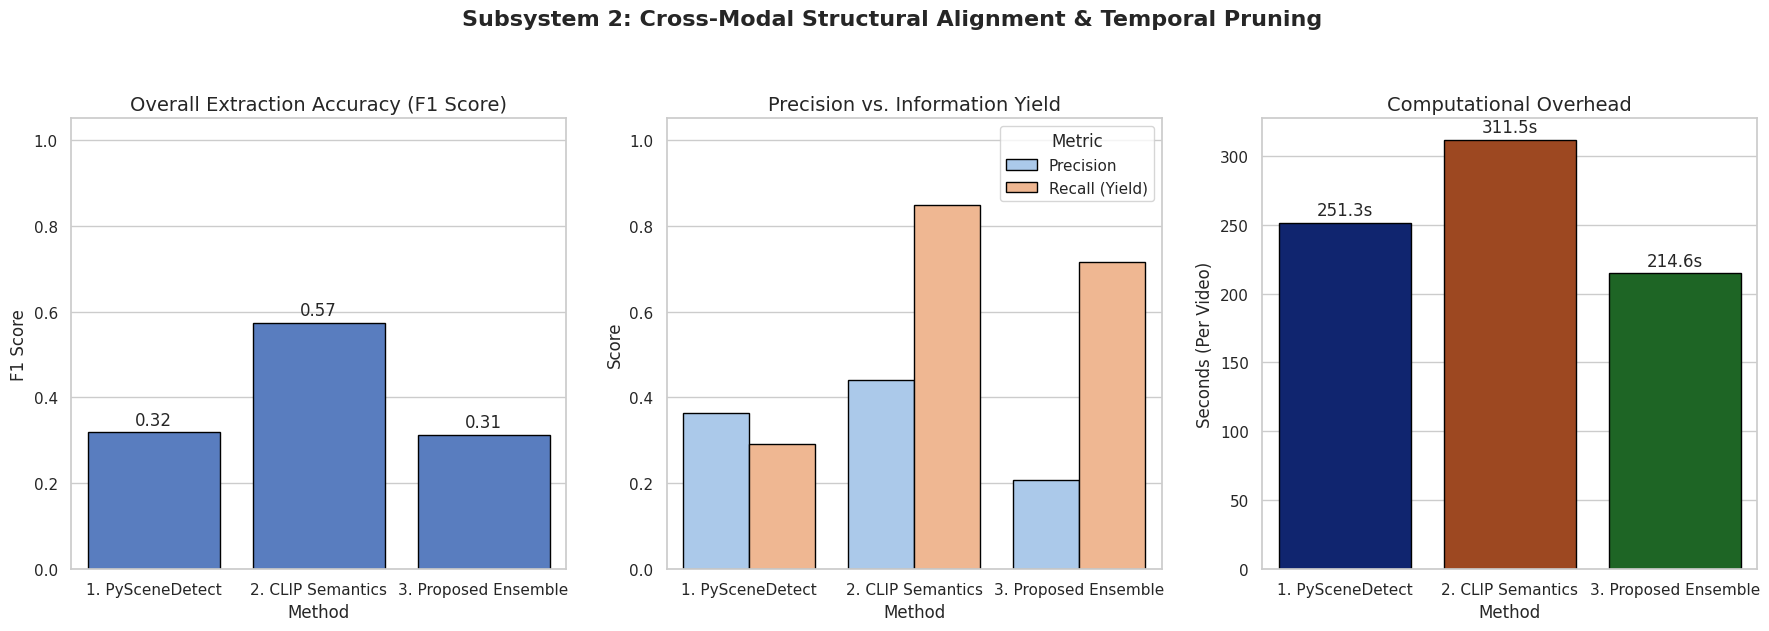


📊 Raw Performance Table:


F1 Score                                         \
Method  1. PySceneDetect 2. CLIP Semantics 3. Proposed Ensemble   
Video                                                             
Video_1         0.338028          0.601770             0.326975   
Video_2         0.352941          0.527660             0.453704   
Video_3         0.267717          0.591133             0.158779   

        Compression Ratio                                         \
Method   1. PySceneDetect 2. CLIP Semantics 3. Proposed Ensemble   
Video                                                              
Video_1          0.999616          0.999060             0.998127   
Video_2          0.999513          0.998835             0.998965   
Video_3          0.999676          0.999183             0.996252   

                Time (s)                                         
Method  1. PySceneDetect 2. CLIP Semantics 3. Proposed Ensemble  
Video                                                            
Video_1       249.659339        314.846992           210.055140  
Video_2       244.222005        297.894691           203.054811  
Video_3       260.024248        321.732407           230.614408

In [17]:
from IPython.display import display

df = pd.DataFrame(results_data)
avg_df = df.groupby("Method").mean(numeric_only=True).reset_index()

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Subsystem 2: Cross-Modal Structural Alignment & Temporal Pruning", fontsize=16, fontweight='bold', y=1.05)

# --- Graph 1: F1 Score (Higher is Better) ---
sns.barplot(ax=axes[0], x="Method", y="F1 Score", data=avg_df, edgecolor="black")
axes[0].set_title("Overall Extraction Accuracy (F1 Score)", fontsize=14)
axes[0].set_ylabel("F1 Score")
axes[0].set_ylim(0, 1.05)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# --- Graph 2: Precision vs Recall Tradeoff ---
# Melting dataframe for grouped bar chart
pr_df = avg_df[["Method", "Precision", "Recall (Yield)"]].melt(id_vars="Method", var_name="Metric", value_name="Score")
sns.barplot(ax=axes[1], x="Method", y="Score", hue="Metric", data=pr_df, edgecolor="black", palette="pastel")
axes[1].set_title("Precision vs. Information Yield", fontsize=14)
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)

# --- Graph 3: Processing Speed (Lower is Better) ---
sns.barplot(ax=axes[2], x="Method", y="Time (s)", data=avg_df, edgecolor="black", palette="dark")
axes[2].set_title("Computational Overhead", fontsize=14)
axes[2].set_ylabel("Seconds (Per Video)")
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}s', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

print("\n📊 Raw Performance Table:")
display(df.pivot(index="Video", columns="Method", values=["F1 Score", "Compression Ratio", "Time (s)"]))

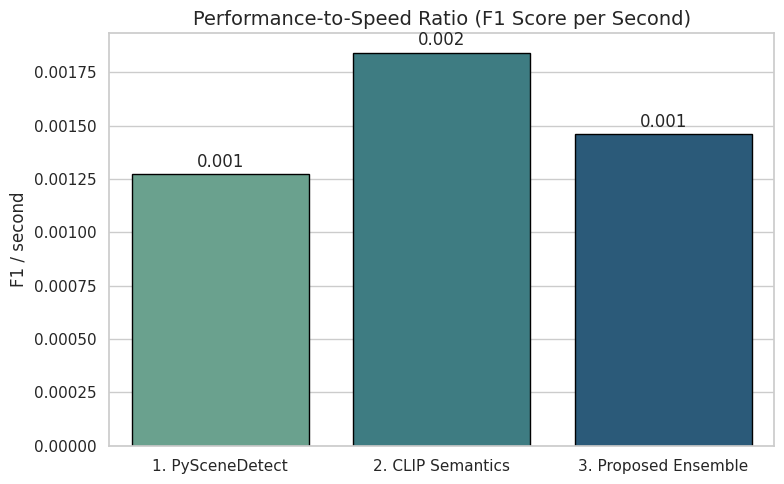

In [18]:
# Performance-to-speed ratio: F1 score per second (higher is better).
perf_speed_df = avg_df.copy()
perf_speed_df["F1 per Second"] = perf_speed_df["F1 Score"] / perf_speed_df["Time (s)"].replace(0, pd.NA)

plt.figure(figsize=(8, 5))
sns.barplot(data=perf_speed_df, x="Method", y="F1 per Second", edgecolor="black", palette="crest")
plt.title("Performance-to-Speed Ratio (F1 Score per Second)", fontsize=14)
plt.ylabel("F1 / second")
plt.xlabel("")
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="center", xytext=(0, 9), textcoords="offset points")
plt.tight_layout()
plt.show()

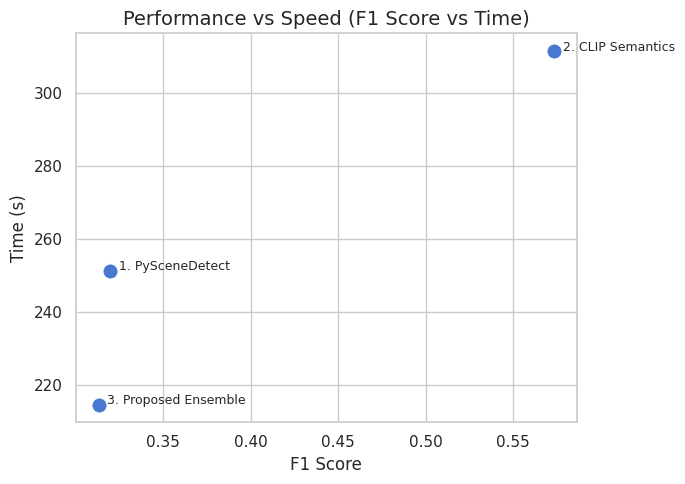

In [20]:
# F1 vs time scatter (lower time, higher F1 is better).
plt.figure(figsize=(7, 5))
sns.scatterplot(data=avg_df, x="F1 Score", y="Time (s)", s=120)

for _, row in avg_df.iterrows():
    plt.text(row["F1 Score"] + 0.005, row["Time (s)"] + 0.1, row["Method"], fontsize=9)

plt.title("Performance vs Speed (F1 Score vs Time)", fontsize=14)
plt.xlabel("F1 Score")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()

In [21]:
# Save raw and aggregated metrics for later plotting.
metrics_dir = os.path.join(BASE_DIR, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

raw_metrics_path = os.path.join(metrics_dir, "metrics_raw_per_video.csv")
avg_metrics_path = os.path.join(metrics_dir, "metrics_avg_by_method.csv")

df.to_csv(raw_metrics_path, index=False)
avg_df.to_csv(avg_metrics_path, index=False)

print(f"✅ Saved raw metrics: {raw_metrics_path}")
print(f"✅ Saved averaged metrics: {avg_metrics_path}")

✅ Saved raw metrics: data/subsys2_pilot/metrics/metrics_raw_per_video.csv
✅ Saved averaged metrics: data/subsys2_pilot/metrics/metrics_avg_by_method.csv


In [22]:
# Show saved metrics tables (falls back to in-memory data if files are missing).
from IPython.display import display

print(f"Raw metrics file: {raw_metrics_path}")
print(f"Exists: {os.path.exists(raw_metrics_path)}")
print(f"Avg metrics file: {avg_metrics_path}")
print(f"Exists: {os.path.exists(avg_metrics_path)}")

raw_df = pd.read_csv(raw_metrics_path) if os.path.exists(raw_metrics_path) else df.copy()
avg_saved_df = pd.read_csv(avg_metrics_path) if os.path.exists(avg_metrics_path) else avg_df.copy()

print("\nRaw metrics (per video):")
display(raw_df)

print("\nAveraged metrics (by method):")
display(avg_saved_df)

Raw metrics file: data/subsys2_pilot/metrics/metrics_raw_per_video.csv
Exists: True
Avg metrics file: data/subsys2_pilot/metrics/metrics_avg_by_method.csv
Exists: True

Raw metrics (per video):


,Method,Video,Time (s),Frames Extracted,Total Frames,Recall (Yield),Precision,F1 Score,Compression Ratio
0,1. PySceneDetect,Video_1,249.659339,58,151089.0,0.285714,0.413793,0.338028,0.999616
1,1. PySceneDetect,Video_2,244.222005,71,145908.0,0.369231,0.338028,0.352941,0.999513
2,1. PySceneDetect,Video_3,260.024248,50,154229.0,0.220779,0.340000,0.267717,0.999676
3,2. CLIP Semantics,Video_1,314.846992,142,151089.0,0.809524,0.478873,0.601770,0.999060
4,2. CLIP Semantics,Video_2,297.894691,170,145908.0,0.953846,0.364706,0.527660,0.998835
5,2. CLIP Semantics,Video_3,321.732407,126,154229.0,0.779221,0.476190,0.591133,0.999183
6,3. Proposed Ensemble,Video_1,210.055140,283,151089.0,0.714286,0.212014,0.326975,0.998127
7,3. Proposed Ensemble,Video_2,203.054811,151,145908.0,0.753846,0.324503,0.453704,0.998965
8,3. Proposed Ensemble,Video_3,230.614408,578,154229.0,0.675325,0.089965,0.158779,0.996252



Averaged metrics (by method):


,Method,Time (s),Frames Extracted,Total Frames,Recall (Yield),Precision,F1 Score,Compression Ratio
0,1. PySceneDetect,251.301864,59.666667,150408.666667,0.291908,0.363940,0.319562,0.999602
1,2. CLIP Semantics,311.491363,146.000000,150408.666667,0.847530,0.439923,0.573521,0.999026
2,3. Proposed Ensemble,214.574786,337.333333,150408.666667,0.714486,0.208828,0.313153,0.997781
